# AIGC 图像的频谱指纹挖掘与伪造检测

本 Notebook 是 Blackboard 提交用的代码实现与结果展示文件。它不重新运行 full-scale 训练，而是读取仓库中已经生成的 CSV、PNG 和模型输出摘要，复现报告中的核心实验结果。展示内容包括数据统计、clean 主结果、单一频域与融合频域对比、跨生成器泛化、鲁棒性诊断、置信度/拒识分析、错误模式分析和复现实验命令。


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display, Image

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'report').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

TABLE_DIR = PROJECT_ROOT / 'report' / 'tables'
FIG_DIR = PROJECT_ROOT / 'report' / 'figures'

pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)


def show_csv(name, n=10, columns=None):
    path = TABLE_DIR / name
    print(path)
    df = pd.read_csv(path)
    if columns:
        df = df[columns]
    display(df.head(n))
    return df


def show_fig(name, width=900):
    path = FIG_DIR / name
    print(path)
    display(Image(filename=str(path), width=width))

## 1. 数据集统计

本项目使用 GenImage 的四个生成源：ADM、BigGAN、VQDM 和 GLIDE。每个生成源包含 `train/ai`、`train/nature`、`val/ai` 和 `val/nature` 四个目录。二分类任务使用 AI 与 nature 两类图像；生成源归因任务只使用 AI 图像，并预测其来自哪个 generator。


In [2]:
dataset_counts = show_csv('dataset_counts.csv')

C:\Users\99303\git\AIGC_Detector\report\tables\dataset_counts.csv


,generator,train_ai,train_nature,val_ai,val_nature
0,ADM,162000,157453,6000,6000
1,BigGAN,162000,162000,6000,6000
2,glide,162000,162000,6000,6000
3,VQDM,162000,162000,6000,6000


## 2. 最终 clean 主结果

最终主模型目录为 `outputs_v2_full_best`，对应配置为 `fusion_freq + flat LightGBM + wide profile + full training`。该模型是报告中的 clean 主结果：二分类和生成源归因都使用同一套频域融合特征，并通过 LightGBM 完成可解释浅层建模。


In [3]:
v2 = show_csv('optimization_v2_summary.csv', n=12, columns=[
    'run', 'feature_profile', 'model_architecture', 'train_augmentation',
    'sample_fraction', 'binary_ai_vs_nature_macro_f1',
    'ai_subsource_attribution_macro_f1', 'combined_macro_f1', 'selected'
])

C:\Users\99303\git\AIGC_Detector\report\tables\optimization_v2_summary.csv


,run,feature_profile,model_architecture,train_augmentation,sample_fraction,binary_ai_vs_nature_macro_f1,ai_subsource_attribution_macro_f1,combined_macro_f1,selected
0,outputs_v2_full_best,fusion_freq,flat,none,1.000,0.991250,0.999083,0.995167,True
1,outputs_v2_5pct_fusion_freq_binary_expert_ense...,fusion_freq,binary_expert_ensemble,none,0.050,0.992500,0.997499,0.994999,False
2,outputs_v2_50pct_best,fusion_freq,flat,none,0.500,0.991125,0.998416,0.994771,False
3,outputs_v2_20pct_best,fusion_freq,flat,none,0.200,0.991042,0.997290,0.994166,False
4,outputs_v2_20pct_fusion_flat_seed123,fusion_freq,flat,none,0.200,0.989167,0.997081,0.993124,False
5,outputs_v2_5pct_fusion_freq_pairwise_ovo_attri...,fusion_freq,pairwise_ovo_attribution,none,0.050,0.987083,0.997499,0.992291,False
6,outputs_v2_5pct_fusion_freq_flat,fusion_freq,flat,none,0.050,0.987083,0.996665,0.991874,False
7,outputs_v2_5pct_color_freq_flat,color_freq,flat,none,0.050,0.983333,0.994161,0.988747,False
8,outputs_v2_smoke_fusion_freq,fusion_freq,flat,none,0.001,0.958333,1.000000,0.979167,False
9,outputs_v2_5pct_block_dct_flat,block_dct,flat,none,0.050,0.936246,0.976639,0.956443,False


C:\Users\99303\git\AIGC_Detector\report\figures\optimization_v2_macro_f1.png


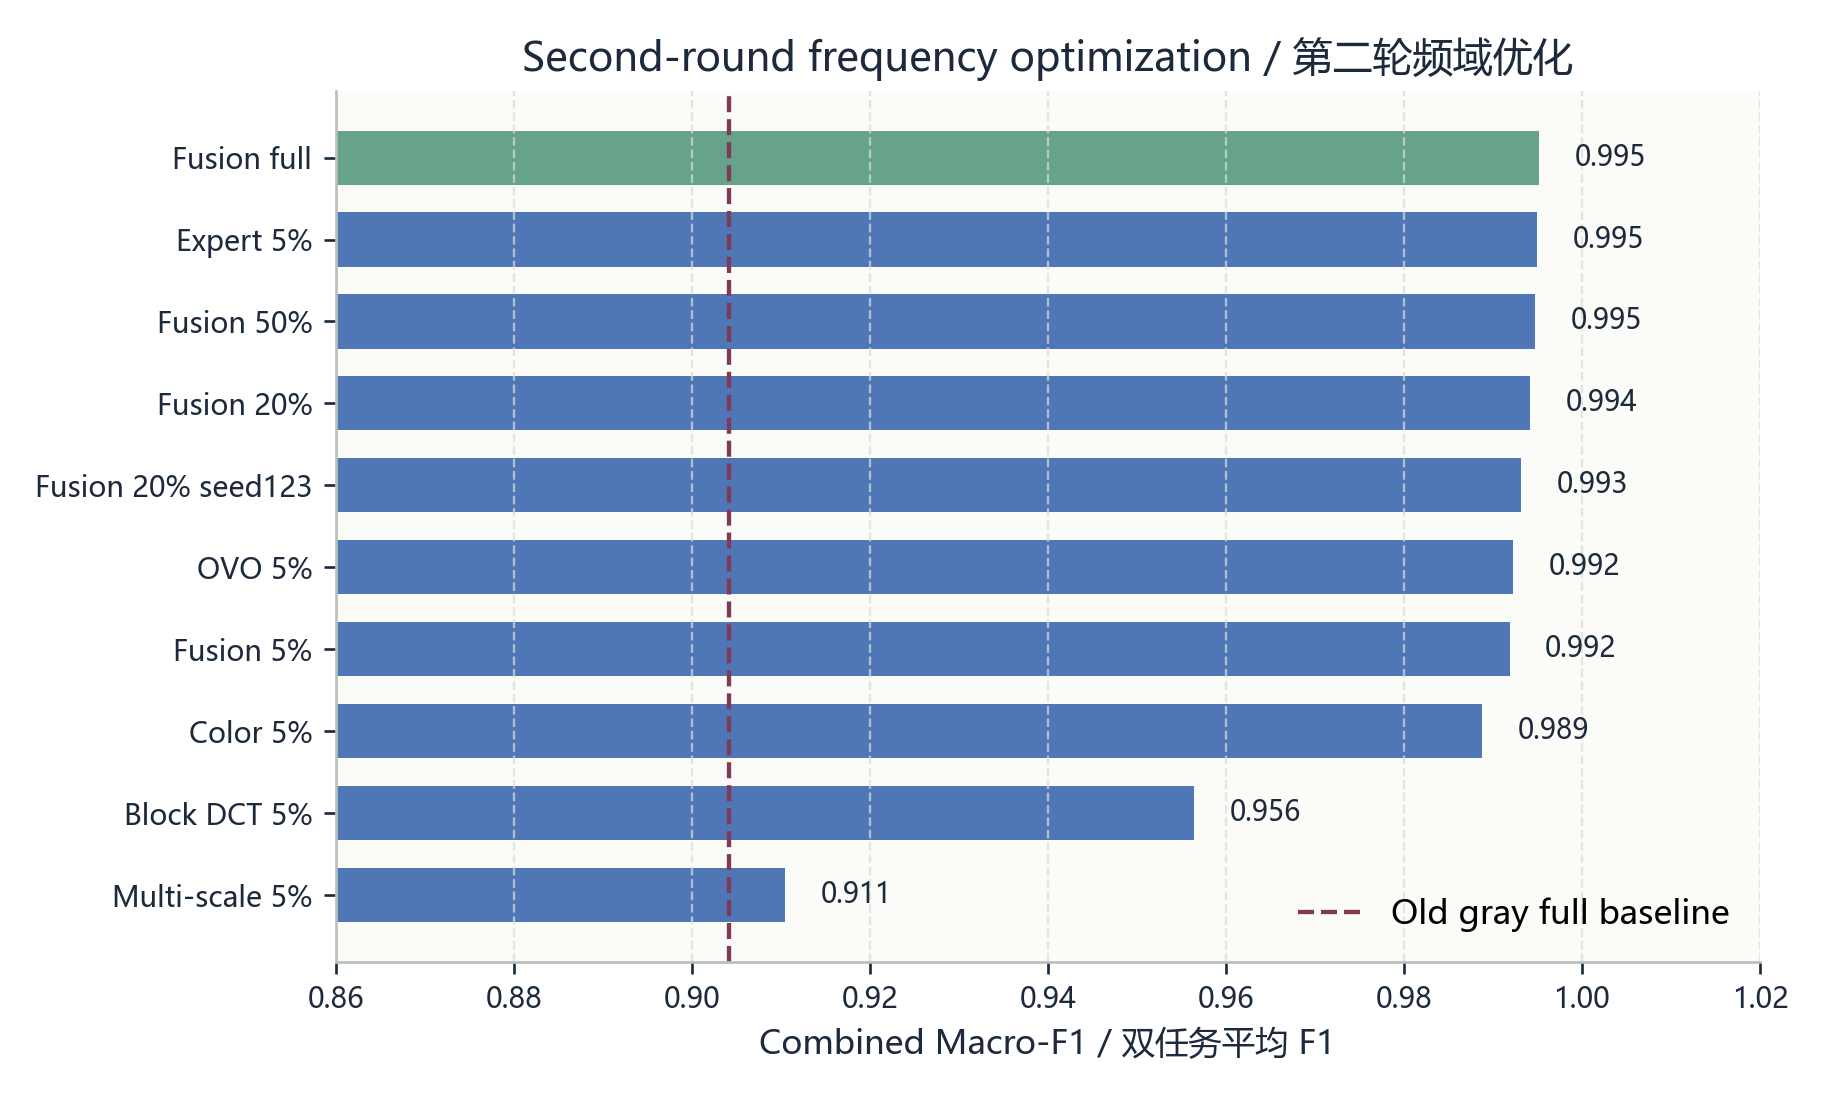

C:\Users\99303\git\AIGC_Detector\report\figures\scaleup_macro_f1.png


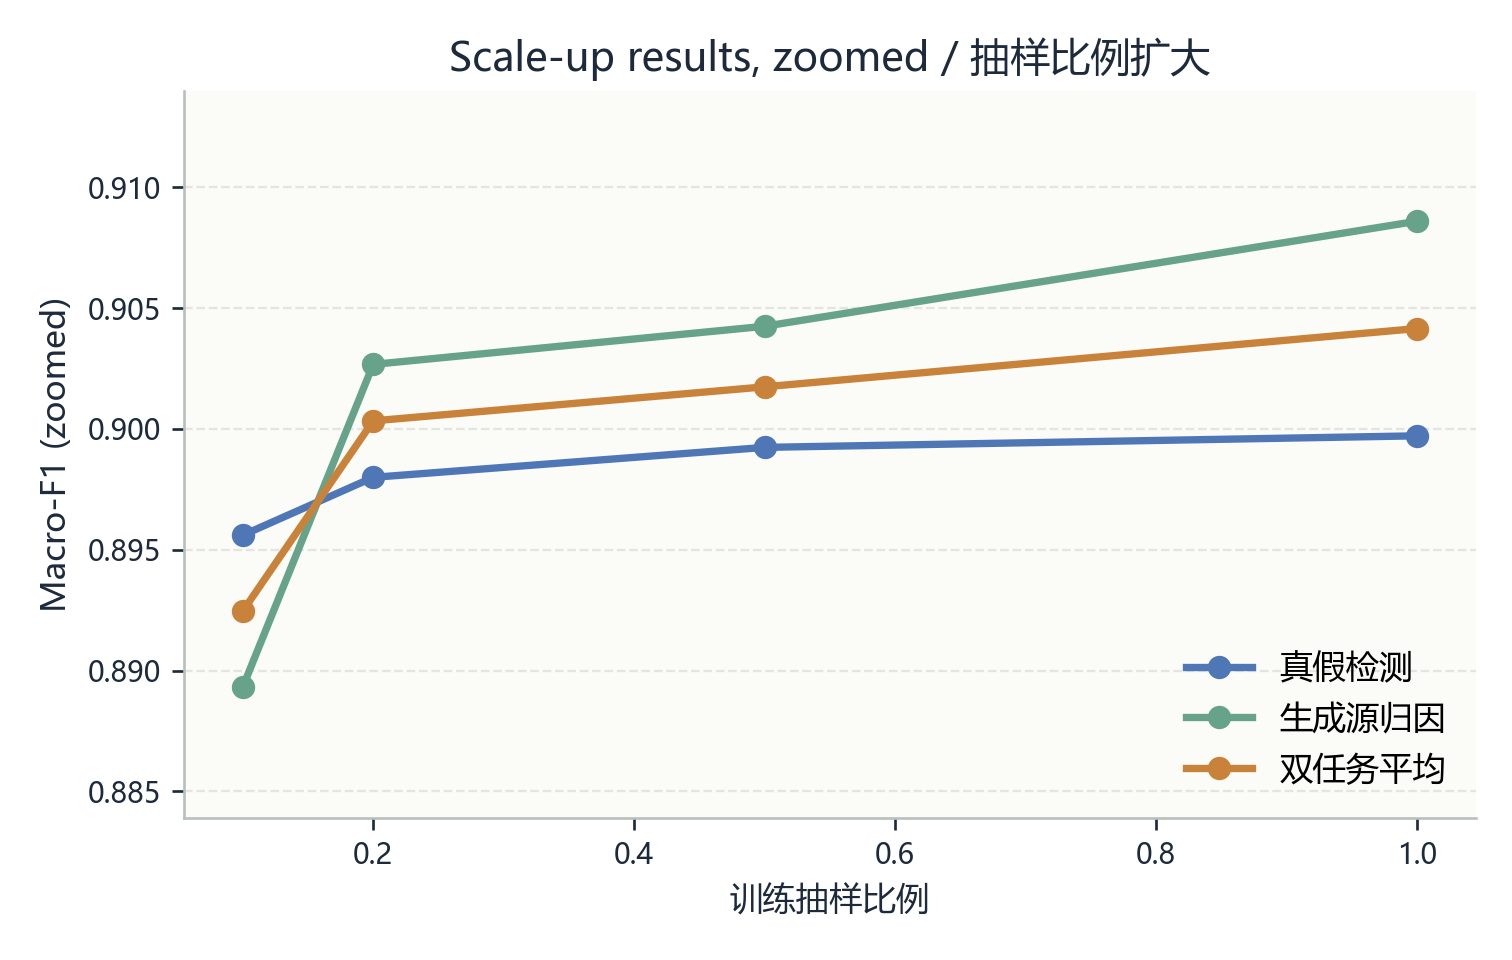

In [4]:
show_fig('optimization_v2_macro_f1.png')
show_fig('scaleup_macro_f1.png')

## 3. 单一频域特征与融合频域特征

这一部分比较不同频域 profile 的贡献，包括 color、multiscale、block-DCT、residual 等单一或局部增强特征，以及最终的 fusion profile。它用于回答：模型性能提升是否来自某一个单独频带，还是来自多类频域统计的互补融合。


C:\Users\99303\git\AIGC_Detector\report\tables\single_vs_fusion_profiles.csv


,profile,family,task,sample_fraction,macro_f1,accuracy,run
0,color_freq,single-domain,ai_subsource_attribution,0.05,0.994161,0.994167,outputs_v2_5pct_color_freq_flat
1,color_freq,single-domain,binary_ai_vs_nature,0.05,0.983333,0.983333,outputs_v2_5pct_color_freq_flat
2,multiscale_freq,single-domain,ai_subsource_attribution,0.05,0.900663,0.901667,outputs_v2_5pct_multiscale_freq_flat
3,multiscale_freq,single-domain,binary_ai_vs_nature,0.05,0.920403,0.920417,outputs_v2_5pct_multiscale_freq_flat
4,block_dct,single-domain,ai_subsource_attribution,0.05,0.976639,0.976667,outputs_v2_5pct_block_dct_flat
5,block_dct,single-domain,binary_ai_vs_nature,0.05,0.936246,0.936250,outputs_v2_5pct_block_dct_flat
6,residual_freq,single-domain,ai_subsource_attribution,0.05,0.895116,0.895833,outputs_v2_5pct_residual_freq_flat
7,residual_freq,single-domain,binary_ai_vs_nature,0.05,0.908750,0.908750,outputs_v2_5pct_residual_freq_flat
8,fusion_freq,fusion,ai_subsource_attribution,0.05,0.996665,0.996667,outputs_v2_5pct_fusion_freq_flat
9,fusion_freq,fusion,binary_ai_vs_nature,0.05,0.987083,0.987083,outputs_v2_5pct_fusion_freq_flat


C:\Users\99303\git\AIGC_Detector\report\figures\single_vs_fusion_feature_profiles.png


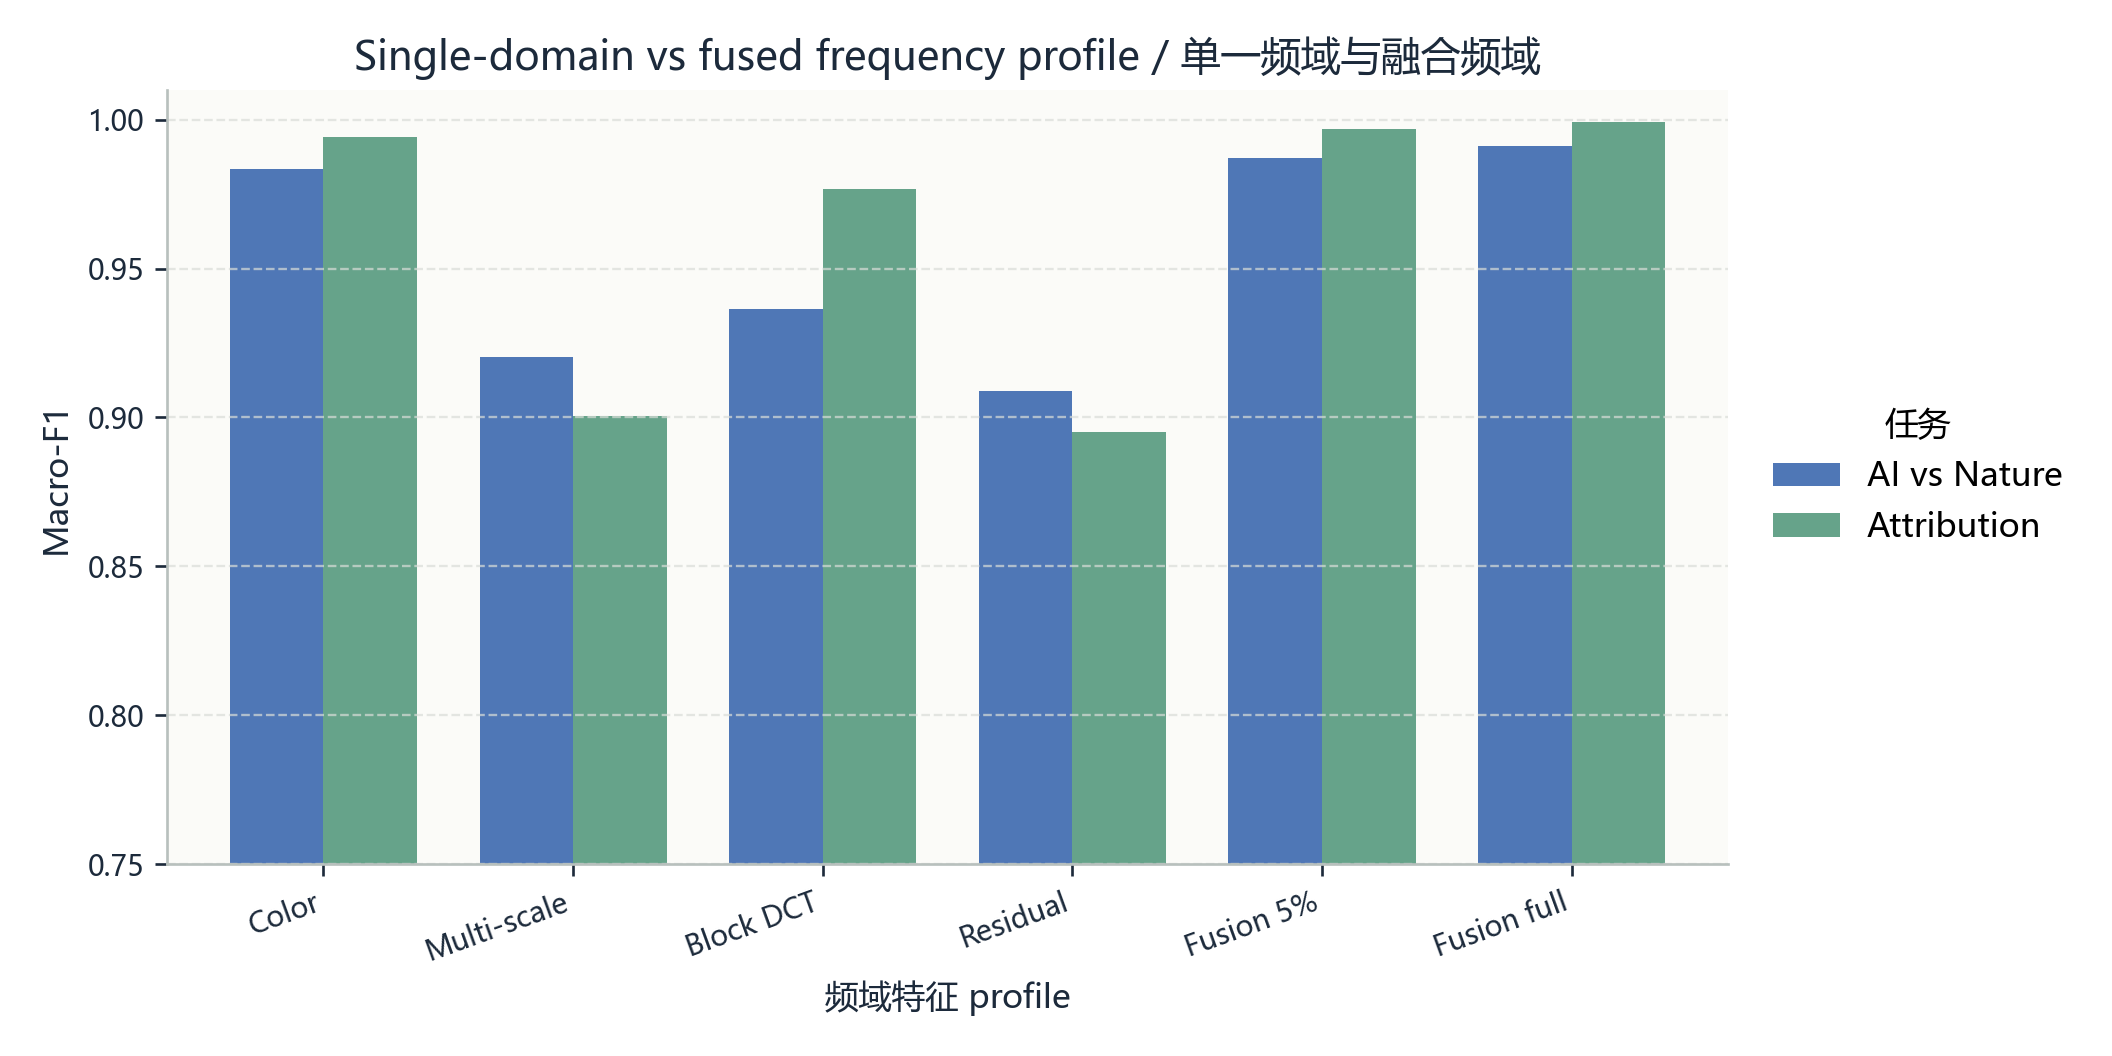

C:\Users\99303\git\AIGC_Detector\report\figures\feature_ablation_binary_ai_vs_nature.png


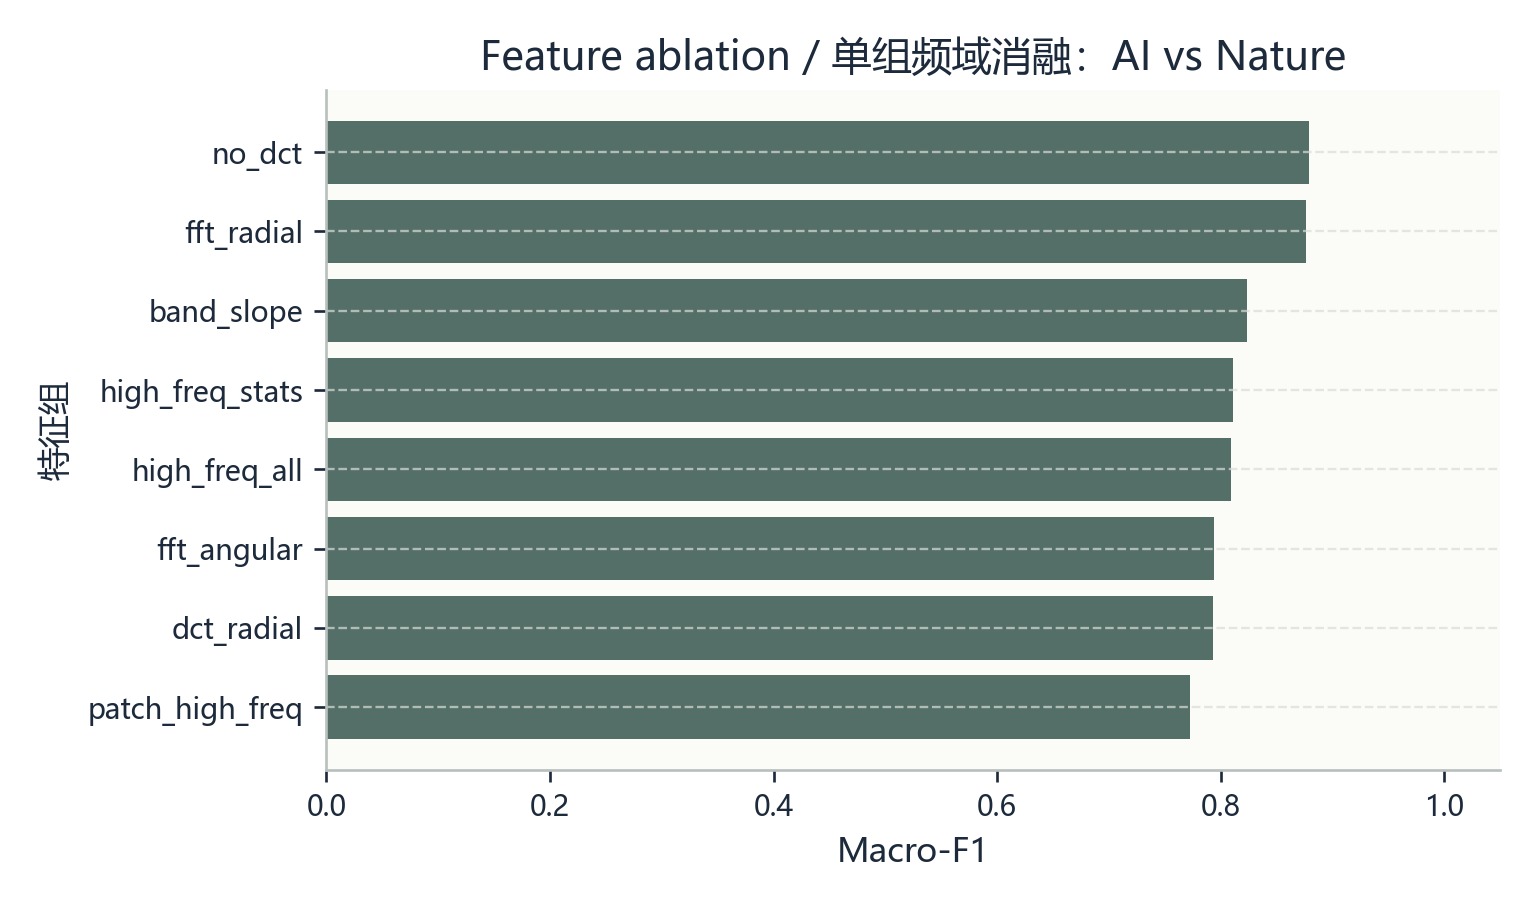

C:\Users\99303\git\AIGC_Detector\report\figures\feature_ablation_ai_subsource_attribution.png


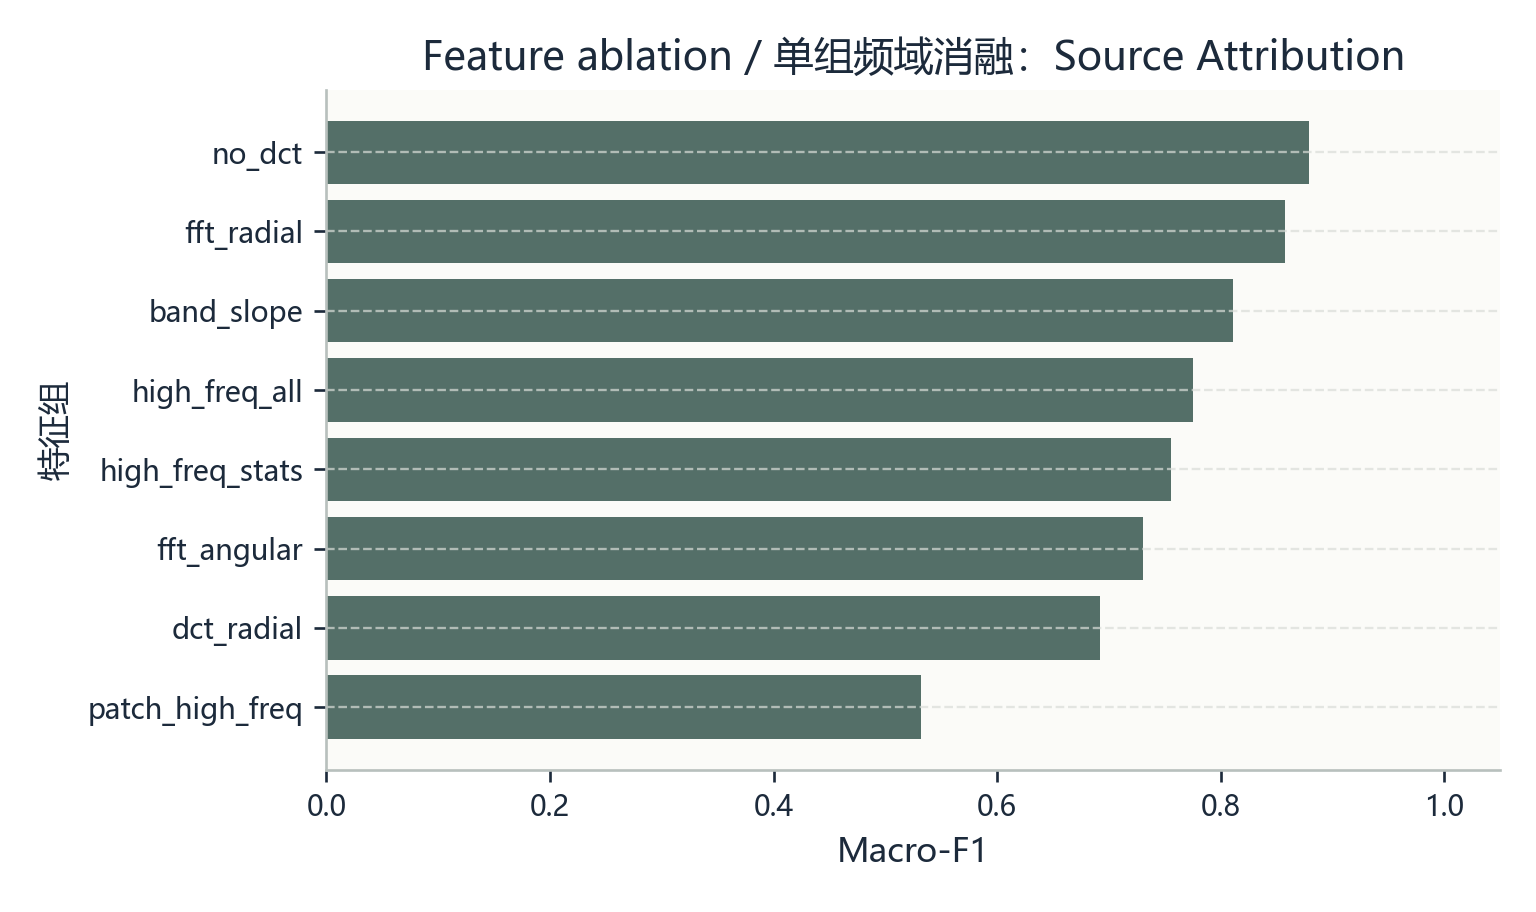

In [5]:
show_csv('single_vs_fusion_profiles.csv', n=20, columns=[
    'profile', 'family', 'task', 'sample_fraction', 'macro_f1', 'accuracy', 'run'
])
show_fig('single_vs_fusion_feature_profiles.png')
show_fig('feature_ablation_binary_ai_vs_nature.png')
show_fig('feature_ablation_ai_subsource_attribution.png')

## 4. 跨 generator 泛化实验

Leave-one-generator-out 实验每次留出一个 generator，只用另外三个 generator 训练二分类模型，再测试 held-out generator。该实验用于检查模型是否学到了较通用的 AIGC 频谱指纹，而不是只记住某几个已见生成器的局部特征。


C:\Users\99303\git\AIGC_Detector\report\tables\logo_generalization.csv


,heldout_generator,train_generators,sample_fraction,feature_profile,accuracy,macro_f1,auc
0,ADM,"BigGAN,VQDM,glide",0.200,fusion_freq,0.627500,0.569641,0.745563
1,BigGAN,"ADM,VQDM,glide",0.200,fusion_freq,0.730833,0.711982,0.928836
2,VQDM,"ADM,BigGAN,glide",0.200,fusion_freq,0.550417,0.438625,0.762068
3,glide,"ADM,BigGAN,VQDM",0.200,fusion_freq,0.888750,0.887691,0.964453
4,ADM,"BigGAN,VQDM,glide",0.001,stable_freq,0.750000,0.733333,0.888889


C:\Users\99303\git\AIGC_Detector\report\figures\logo_generalization_macro_f1.png


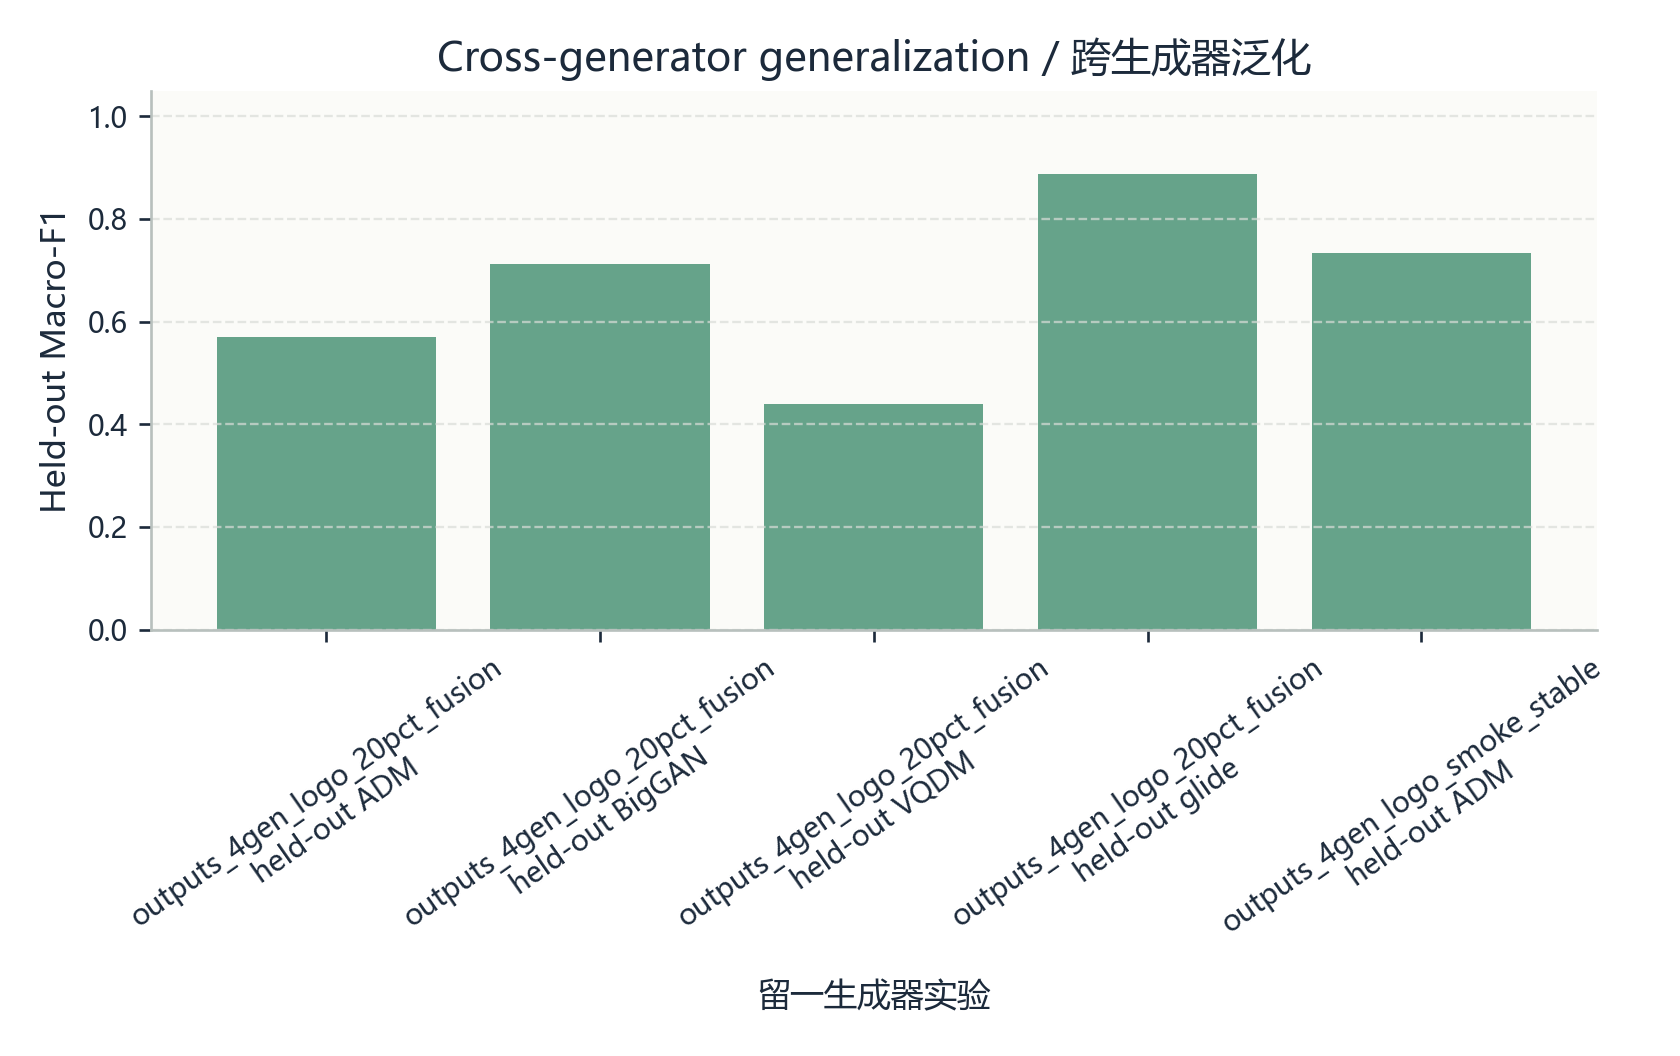

In [6]:
logo = show_csv('logo_generalization.csv', n=10, columns=[
    'heldout_generator', 'train_generators', 'sample_fraction',
    'feature_profile', 'accuracy', 'macro_f1', 'auc'
])
show_fig('logo_generalization_macro_f1.png')

## 5. 鲁棒性诊断

鲁棒性评估不重新训练模型，而是在同一 validation 子集上施加 JPEG 压缩、resize 和 Gaussian noise，再重新提取频域特征并评估模型输出。该部分展示 clean 高分模型在 degraded 图像上的性能退化，并与旧灰度 baseline 进行对照。


In [7]:
robust_cmp = show_csv('robustness_comparison.csv', n=25, columns=[
    'run', 'task', 'attack', 'level', 'n_samples', 'macro_f1', 'accuracy', 'auc'
])

C:\Users\99303\git\AIGC_Detector\report\tables\robustness_comparison.csv


,run,task,attack,level,n_samples,macro_f1,accuracy,auc
0,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,clean,none,9600,0.990833,0.990833,0.999628
1,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,jpeg,95,9600,0.660730,0.683646,0.787743
2,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,jpeg,75,9600,0.579960,0.612500,0.665828
3,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,jpeg,50,9600,0.566565,0.598750,0.633951
4,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,resize,0.5,9600,0.367118,0.511042,0.412542
5,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,resize,0.75,9600,0.637942,0.674583,0.792209
6,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,resize,1.5,9600,0.813555,0.818542,0.919892
7,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,noise,2,9600,0.748085,0.760312,0.815550
8,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,noise,5,9600,0.433913,0.529896,0.563054
9,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,noise,10,9600,0.337735,0.447708,0.420701


C:\Users\99303\git\AIGC_Detector\report\figures\robustness_comparison_binary_ai_vs_nature.png


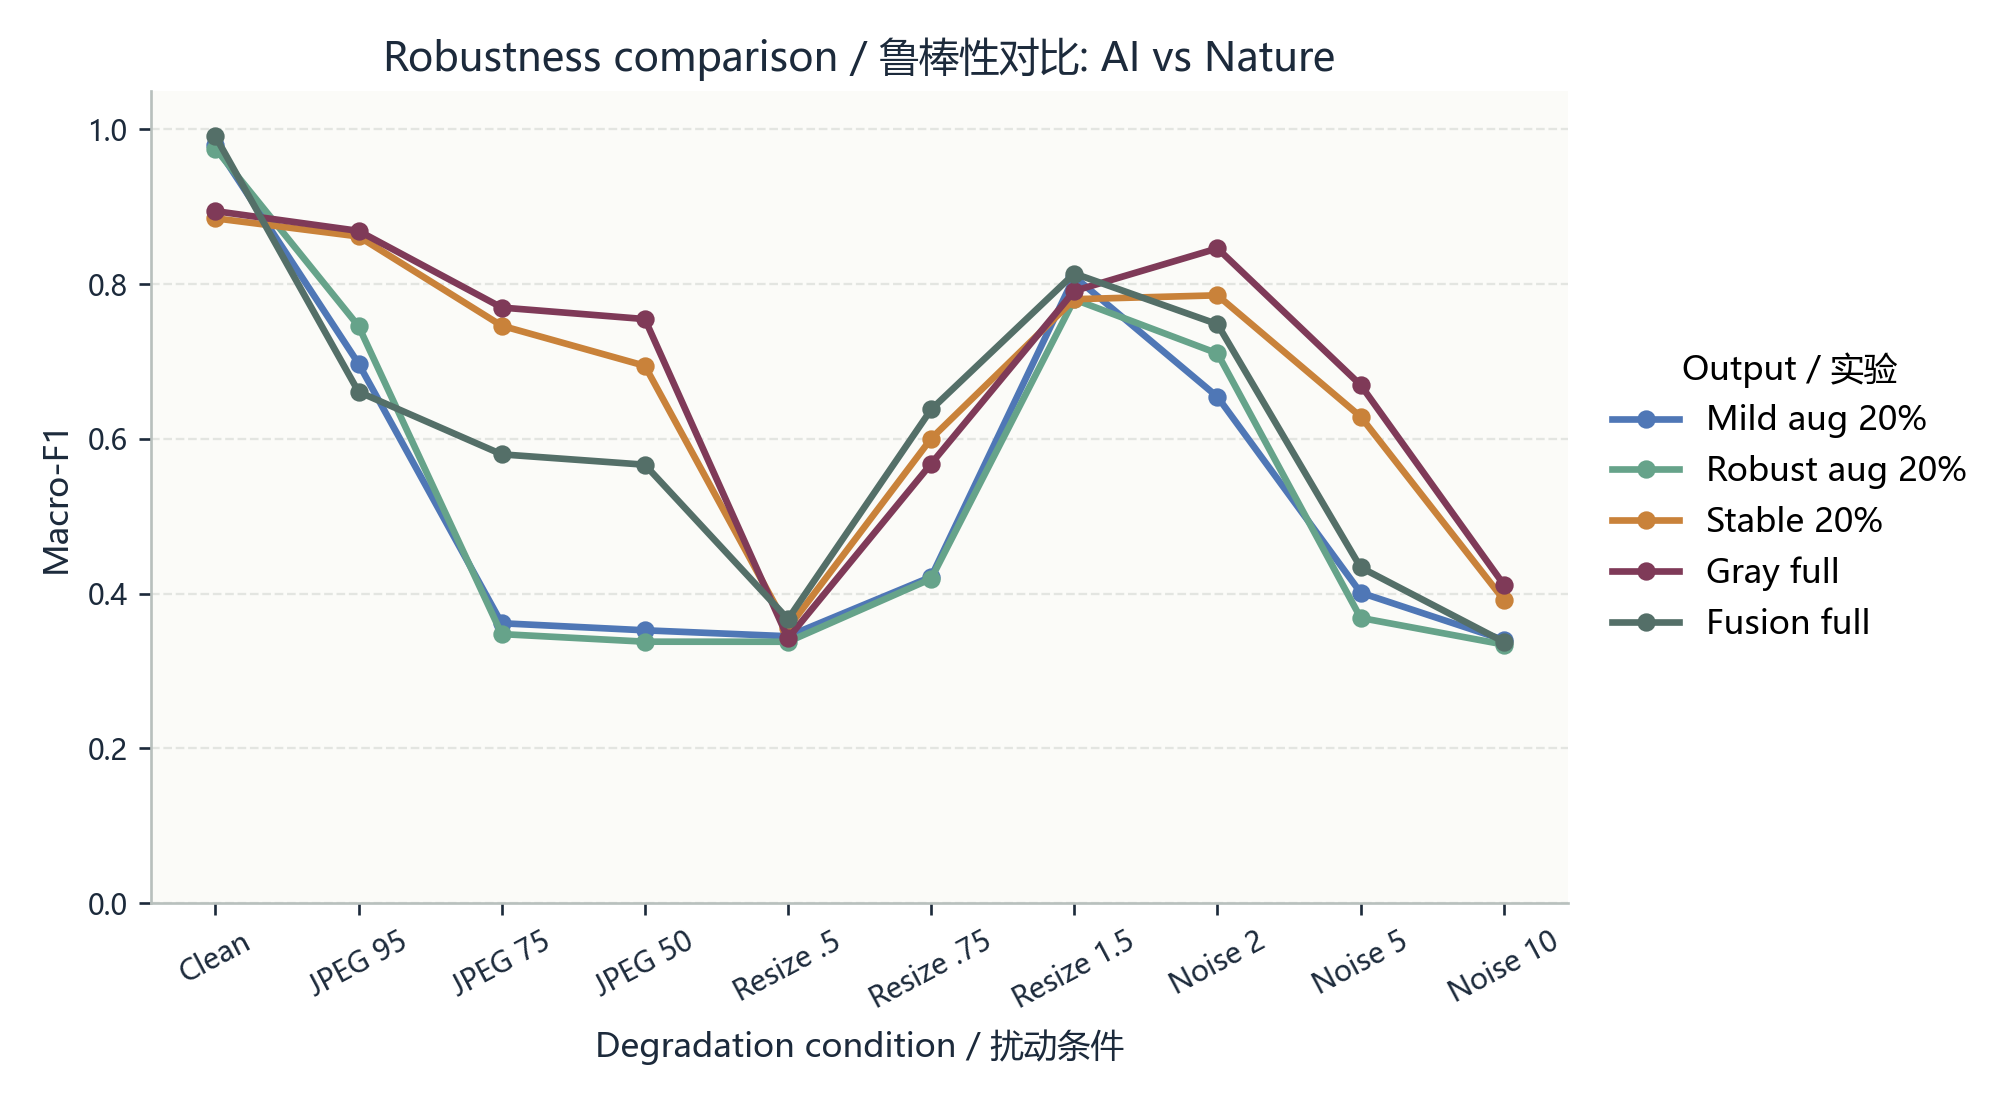

C:\Users\99303\git\AIGC_Detector\report\figures\robustness_comparison_ai_subsource_attribution.png


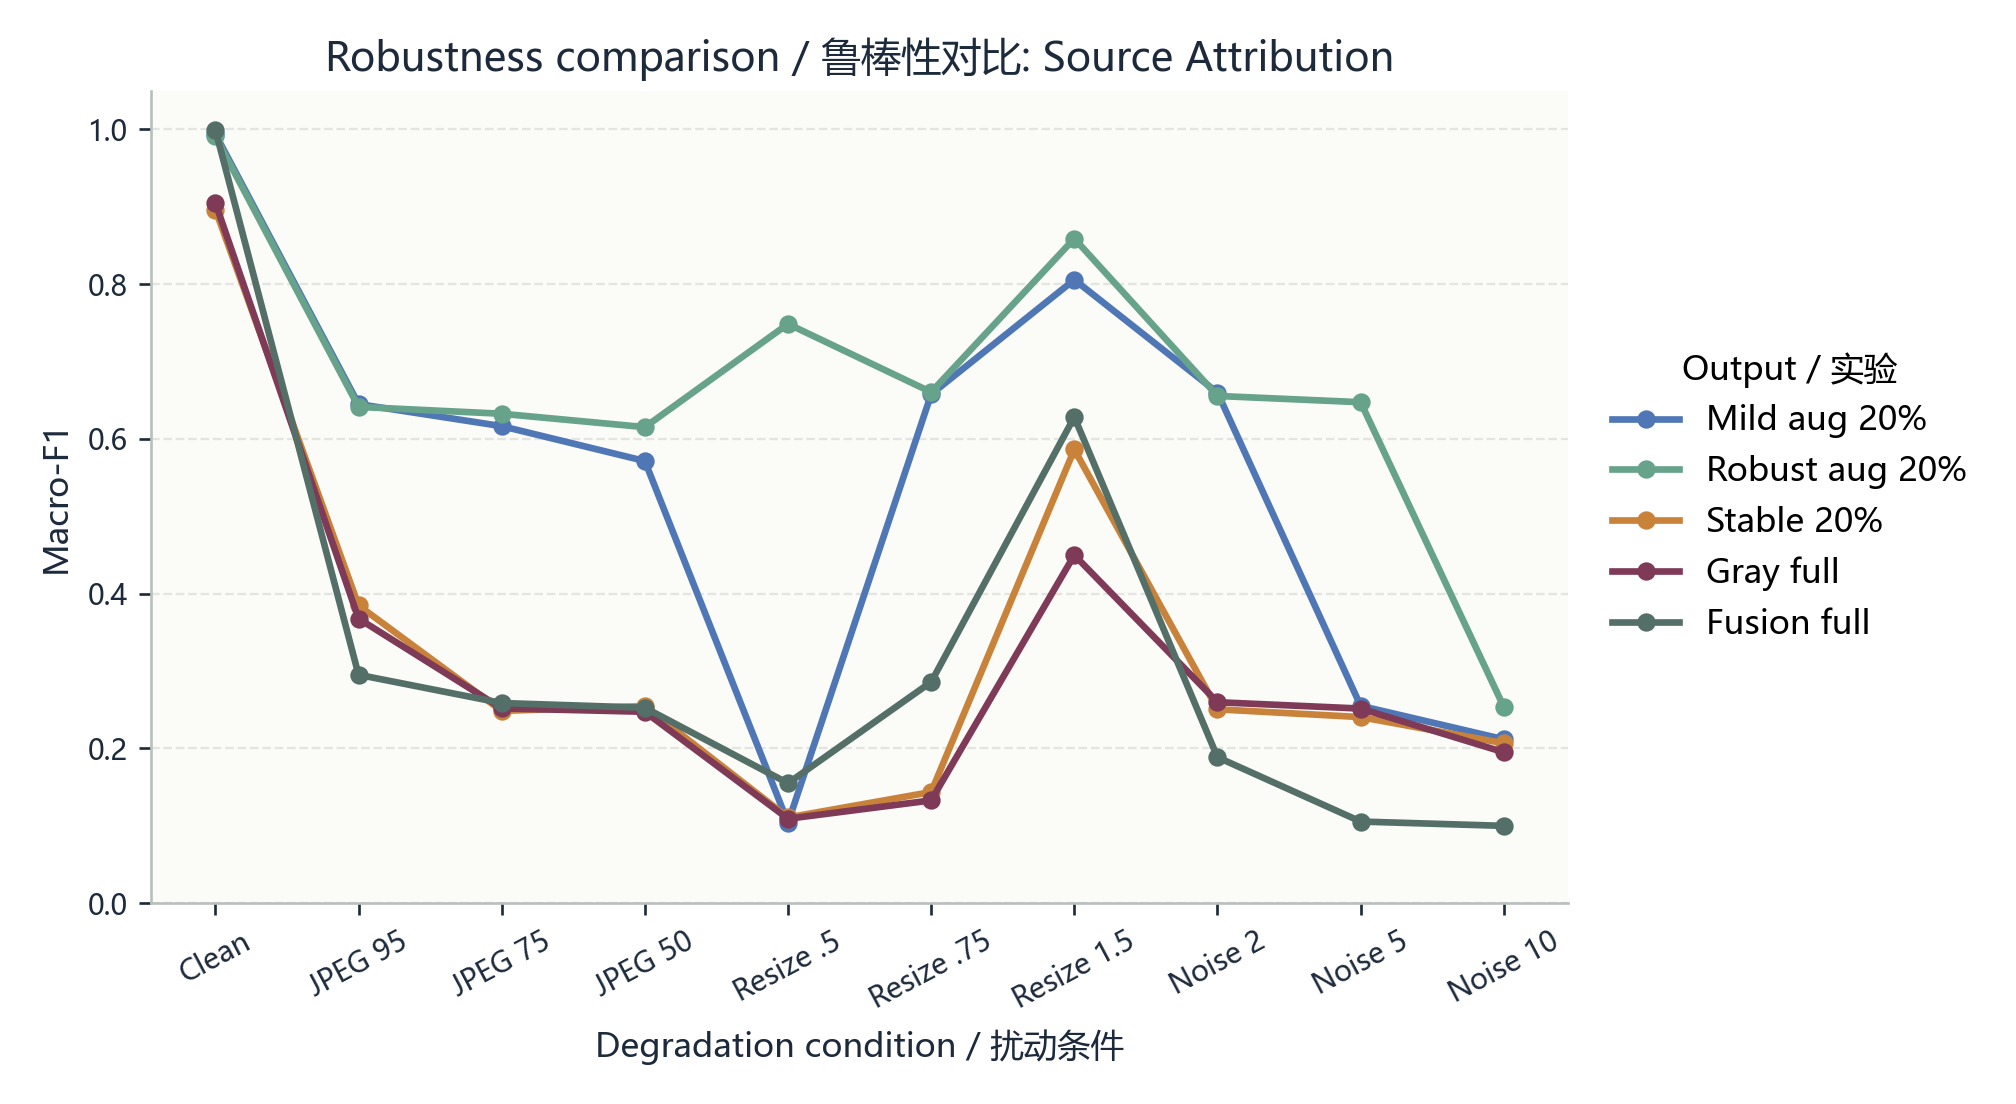

In [8]:
show_fig('robustness_comparison_binary_ai_vs_nature.png')
show_fig('robustness_comparison_ai_subsource_attribution.png')

## 6. Clean-vs-Robustness 权衡

`fusion_freq` 在 clean validation 上最强，但在 degraded 场景下可能明显退化；`stable_freq` 和鲁棒训练配置则用于观察是否能换取更稳定的扰动表现。本节关注的不是单一最高 F1，而是 clean 性能与鲁棒性之间的取舍。


C:\Users\99303\git\AIGC_Detector\report\tables\robustness_tradeoff.csv


,run,task,clean_macro_f1,degraded_mean_macro_f1,degraded_min_macro_f1,clean_minus_degraded_mean
0,outputs_4gen_20pct_fusion_mild_aug_robust_20pct,ai_subsource_attribution,0.993744,0.502922,0.103995,0.490821
1,outputs_4gen_20pct_fusion_mild_aug_robust_20pct,binary_ai_vs_nature,0.979477,0.487034,0.340193,0.492444
2,outputs_4gen_20pct_fusion_robust_aug_robust_20pct,ai_subsource_attribution,0.990631,0.634743,0.253682,0.355888
3,outputs_4gen_20pct_fusion_robust_aug_robust_20pct,binary_ai_vs_nature,0.974891,0.486868,0.334259,0.488023
4,outputs_4gen_20pct_stable_freq_robust_20pct,ai_subsource_attribution,0.896171,0.269633,0.110826,0.626538
5,outputs_4gen_20pct_stable_freq_robust_20pct,binary_ai_vs_nature,0.884874,0.649341,0.355347,0.235533
6,outputs_4gen_full_best_robust_20pct,ai_subsource_attribution,0.904850,0.251700,0.109203,0.653150
7,outputs_4gen_full_best_robust_20pct,binary_ai_vs_nature,0.894157,0.669061,0.342396,0.225097
8,outputs_v2_full_best_robust_20pct,ai_subsource_attribution,0.999167,0.252206,0.100000,0.746961
9,outputs_v2_full_best_robust_20pct,binary_ai_vs_nature,0.990833,0.571734,0.337735,0.419100


C:\Users\99303\git\AIGC_Detector\report\figures\robustness_tradeoff_binary_ai_vs_nature.png


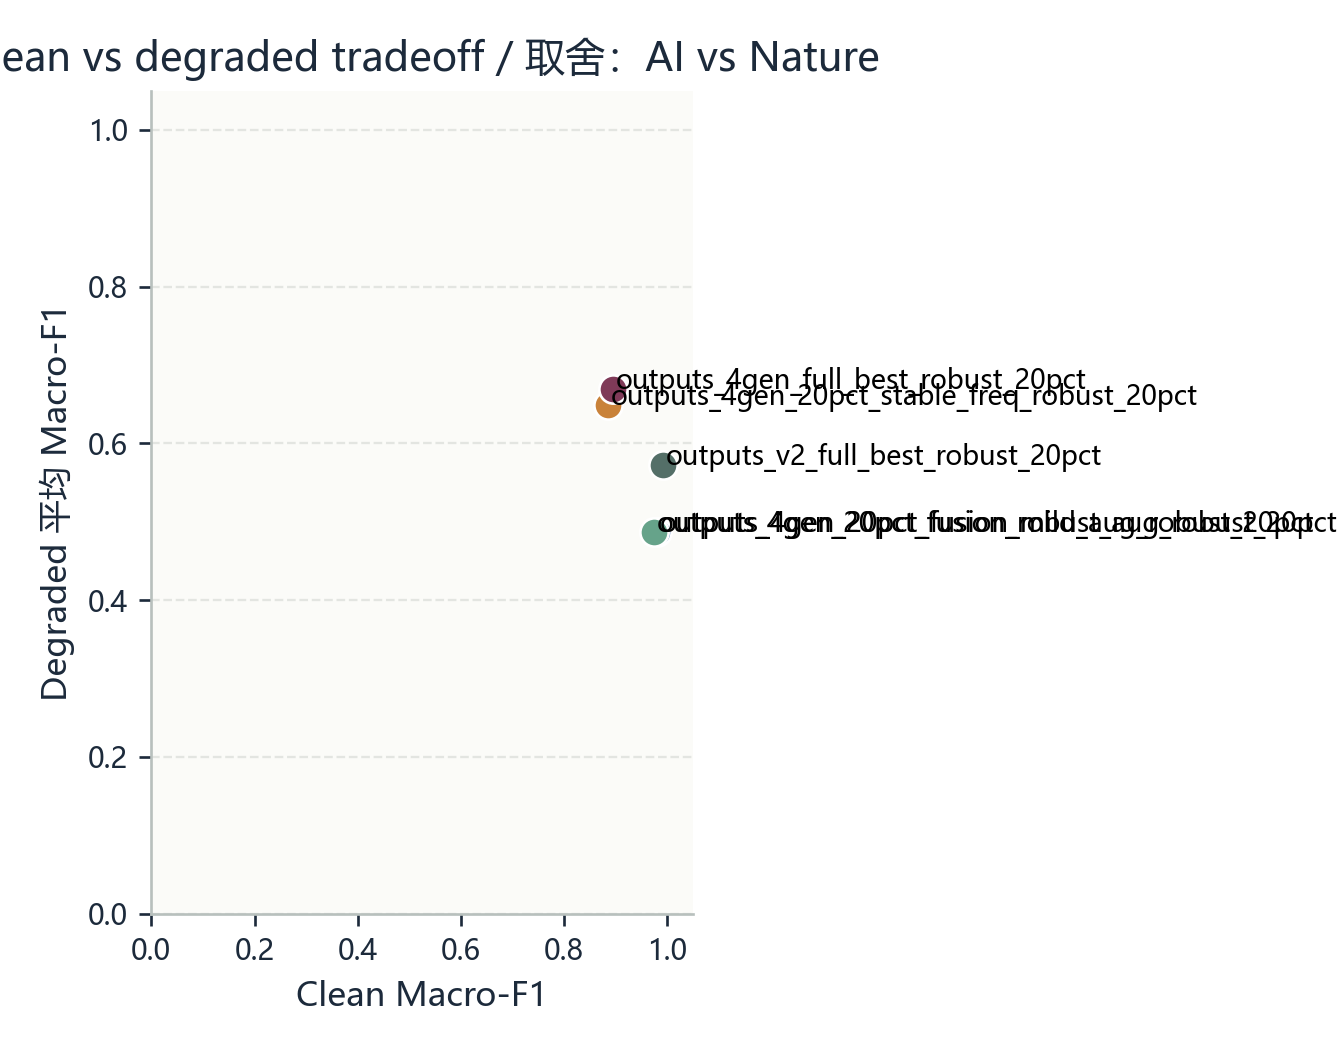

C:\Users\99303\git\AIGC_Detector\report\figures\robustness_tradeoff_ai_subsource_attribution.png


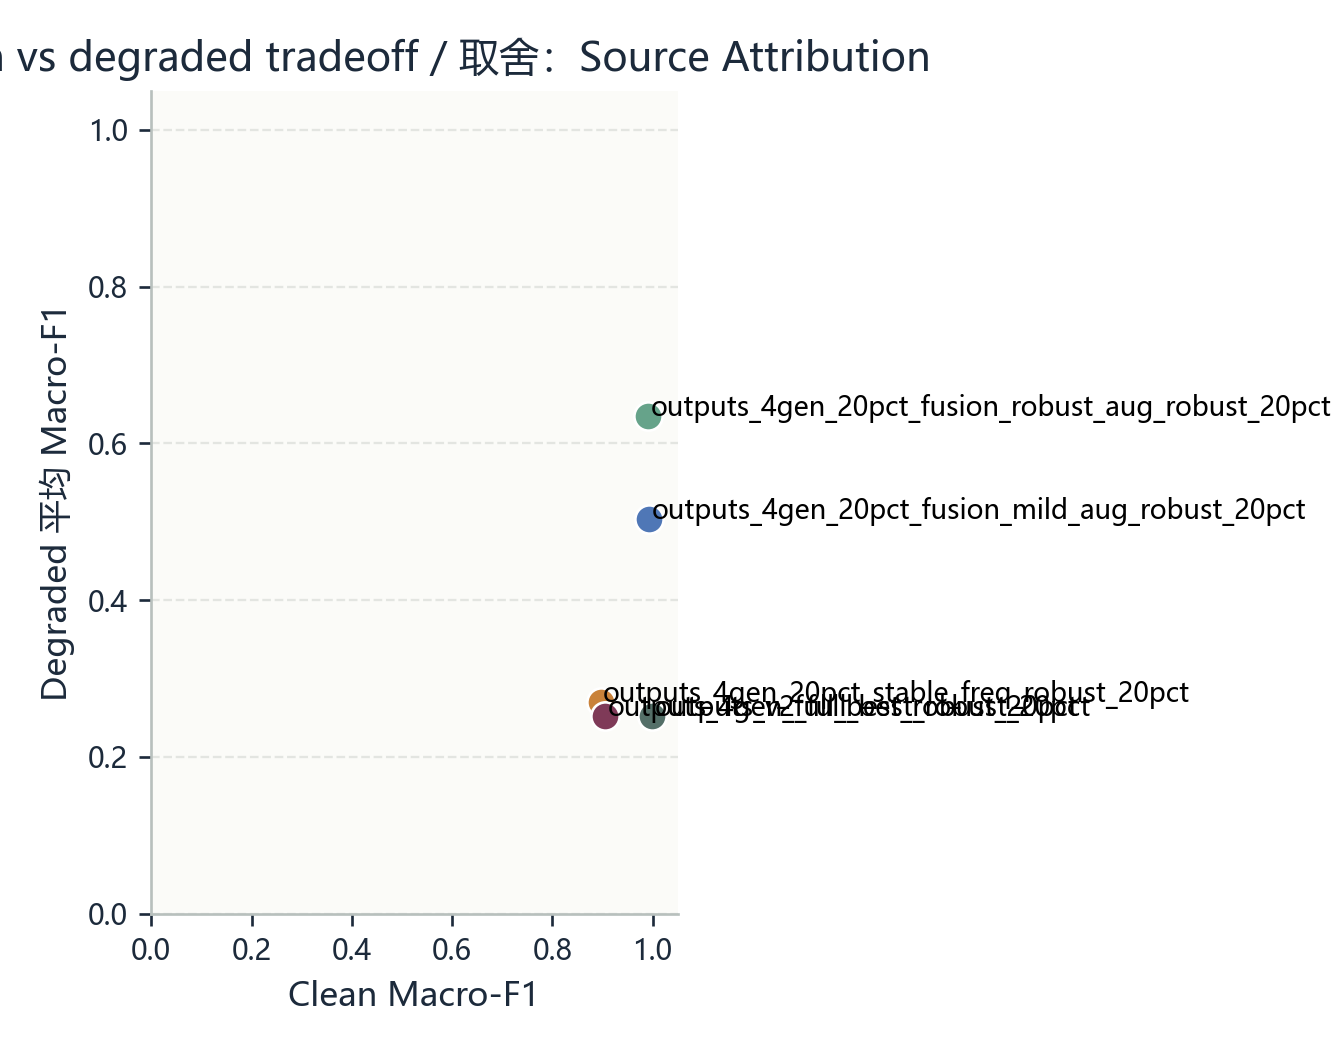

In [9]:
tradeoff = show_csv('robustness_tradeoff.csv', n=20)
show_fig('robustness_tradeoff_binary_ai_vs_nature.png')
show_fig('robustness_tradeoff_ai_subsource_attribution.png')

## 7. 混淆矩阵与特征重要性

混淆矩阵用于查看二分类和归因任务的主要错误模式，特征重要性用于解释 LightGBM 依赖哪些频域统计。报告中重点关注颜色频谱、多尺度频谱、block-DCT 和高频残差等特征族。


C:\Users\99303\git\AIGC_Detector\report\figures\confusion_binary_ai_vs_nature_lightgbm.png


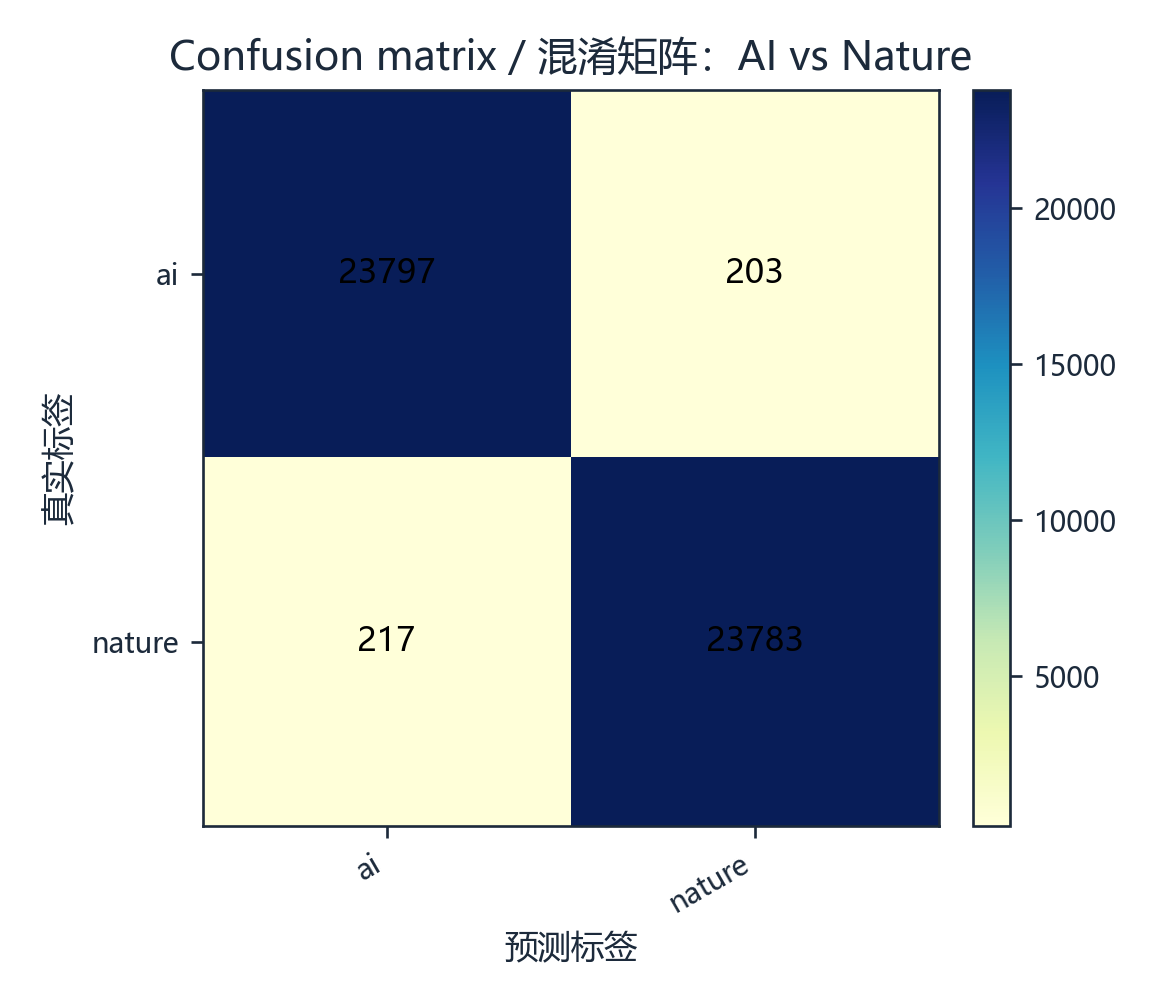

C:\Users\99303\git\AIGC_Detector\report\figures\confusion_ai_subsource_attribution_lightgbm.png


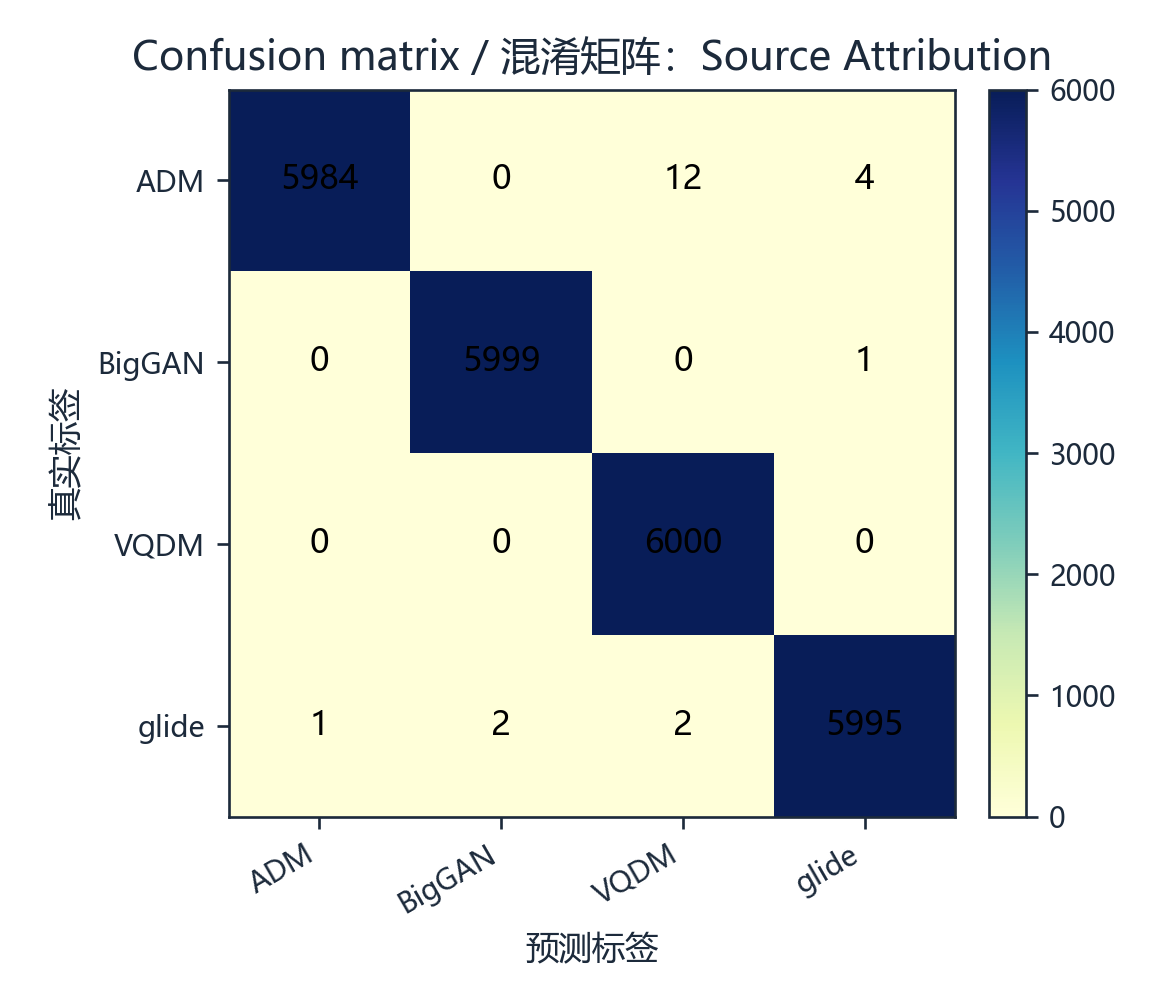

C:\Users\99303\git\AIGC_Detector\report\tables\top_features_binary_ai_vs_nature.csv


,feature,importance
0,color_ycbcr_cr_hf_std,751.0
1,color_ycbcr_cr_band_mid,697.0
2,block_dct_zigzag_std_9,683.0
3,color_ycbcr_cr_hf_skew,645.0
4,block_dct_zigzag_std_5,627.0
5,color_ycbcr_cb_hf_skew,590.0
6,color_ycbcr_cr_band_high,583.0
7,color_ycbcr_cb_hf_std,557.0
8,color_ycbcr_cb_band_mid,550.0
9,block_dct_band_mid_mean,547.0


,feature,importance
0,color_ycbcr_cr_hf_std,751.0
1,color_ycbcr_cr_band_mid,697.0
2,block_dct_zigzag_std_9,683.0
3,color_ycbcr_cr_hf_skew,645.0
4,block_dct_zigzag_std_5,627.0
5,color_ycbcr_cb_hf_skew,590.0
6,color_ycbcr_cr_band_high,583.0
7,color_ycbcr_cb_hf_std,557.0
8,color_ycbcr_cb_band_mid,550.0
9,block_dct_band_mid_mean,547.0


In [10]:
show_fig('confusion_binary_ai_vs_nature_lightgbm.png', width=650)
show_fig('confusion_ai_subsource_attribution_lightgbm.png', width=650)
show_csv('top_features_binary_ai_vs_nature.csv', n=20)

## 8. 置信度与拒识分析

除了预测类别，本项目还导出预测概率、margin 和 entropy，并绘制 coverage-accuracy 曲线。该分析用于说明：当模型置信度不足时，可以选择输出“不确定”并交给人工复核，从而提升高覆盖率之外的使用安全性。


C:\Users\99303\git\AIGC_Detector\report\tables\confidence_by_generator_binary_ai_vs_nature.csv


,generator,n_samples,accuracy,mean_confidence,mean_margin,mean_entropy
0,ADM,12000,0.988667,0.980664,0.961327,0.083266
1,BigGAN,12000,0.995250,0.990803,0.981605,0.044664
2,VQDM,12000,0.987917,0.972484,0.944967,0.118316
3,glide,12000,0.993167,0.988023,0.976047,0.053891


C:\Users\99303\git\AIGC_Detector\report\tables\confidence_by_generator_ai_subsource_attribution.csv


,generator,n_samples,accuracy,mean_confidence,mean_margin,mean_entropy
0,ADM,6000,0.997333,0.999102,0.998207,0.001614
1,BigGAN,6000,0.999833,0.999975,0.999950,0.000053
2,VQDM,6000,1.000000,0.999704,0.999437,0.000522
3,glide,6000,0.999167,0.999629,0.999259,0.000727


C:\Users\99303\git\AIGC_Detector\report\figures\confidence_coverage_binary_ai_vs_nature.png


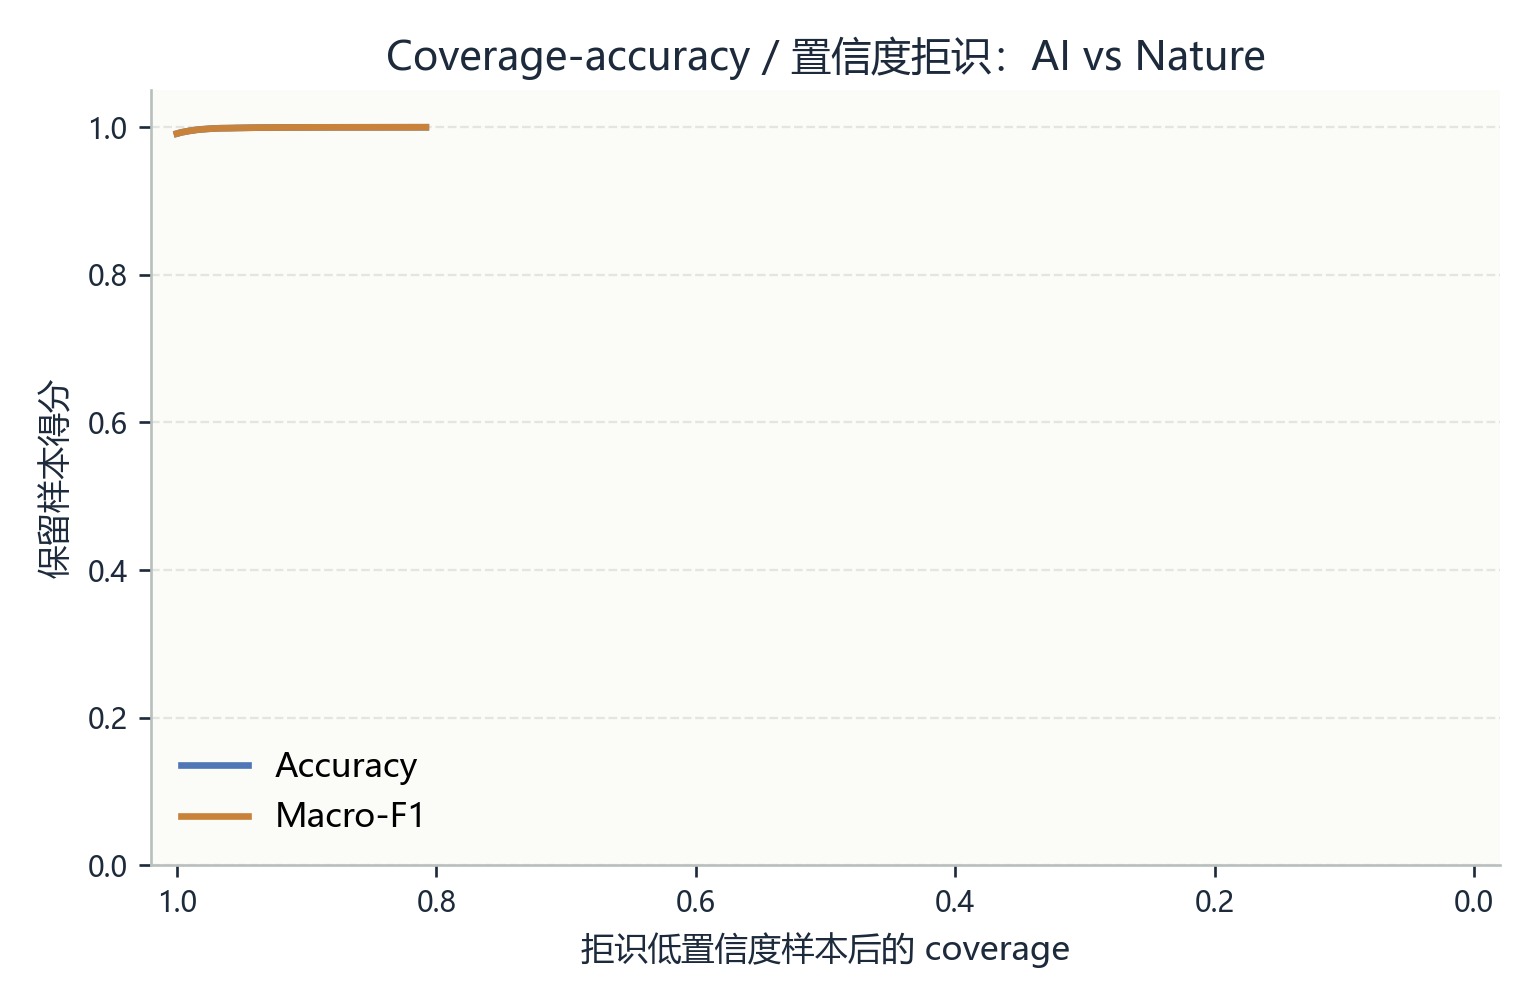

C:\Users\99303\git\AIGC_Detector\report\figures\confidence_histogram_binary_ai_vs_nature.png


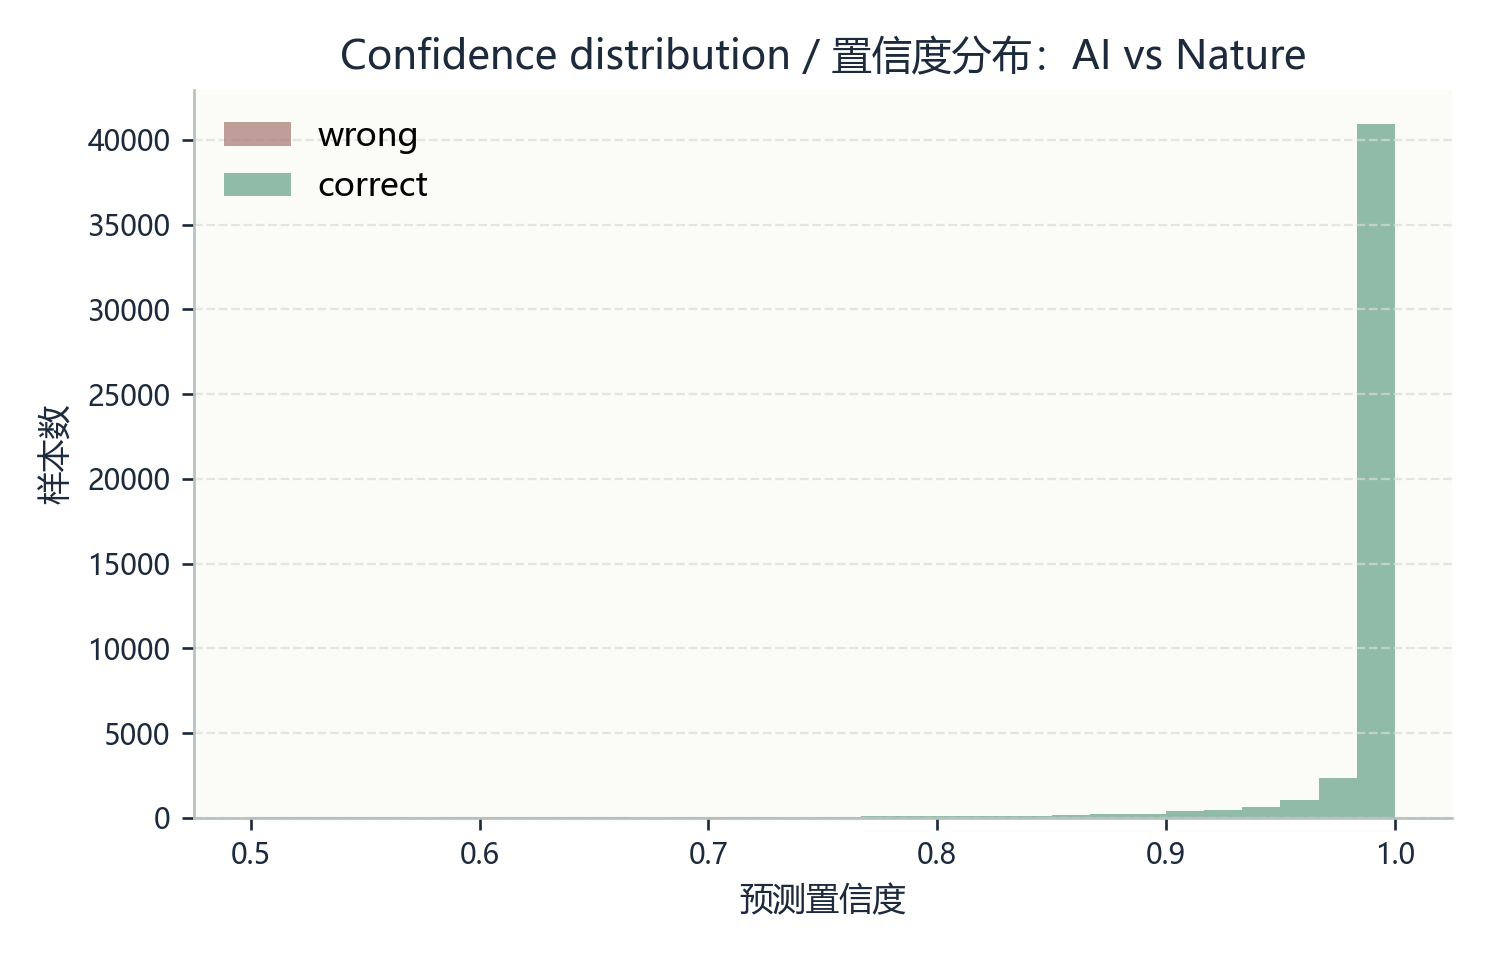

In [11]:
show_csv('confidence_by_generator_binary_ai_vs_nature.csv')
show_csv('confidence_by_generator_ai_subsource_attribution.csv')
show_fig('confidence_coverage_binary_ai_vs_nature.png')
show_fig('confidence_histogram_binary_ai_vs_nature.png')

## 9. 错误模式分析

错误分析按 generator、真实标签和预测标签统计误判情况。二分类中关注 AI 被判成 nature 或 nature 被判成 AI 的分布；归因任务中重点检查 ADM/VQDM 等生成源之间是否存在系统性混淆。


In [12]:
show_csv('v2_error_breakdown_binary_ai_vs_nature.csv', n=10)
show_csv('v2_error_breakdown_ai_subsource_attribution.csv', n=10)

C:\Users\99303\git\AIGC_Detector\report\tables\v2_error_breakdown_binary_ai_vs_nature.csv


,generator,true_label,pred_label,errors,mean_confidence
0,ADM,ai,nature,1703,0.744853
1,VQDM,ai,nature,822,0.681645
2,ADM,nature,ai,567,0.675598
3,VQDM,nature,ai,536,0.683533
4,BigGAN,nature,ai,509,0.682890
5,glide,nature,ai,507,0.678668
6,glide,ai,nature,166,0.718399
7,BigGAN,ai,nature,3,0.699905


C:\Users\99303\git\AIGC_Detector\report\tables\v2_error_breakdown_ai_subsource_attribution.csv


,generator,true_label,pred_label,errors,mean_confidence
0,ADM,ADM,VQDM,990,0.673908
1,VQDM,VQDM,ADM,830,0.667530
2,ADM,ADM,glide,189,0.760765
3,glide,glide,ADM,153,0.727695
4,glide,glide,VQDM,16,0.641493
5,glide,glide,BigGAN,5,0.878660
6,BigGAN,BigGAN,glide,3,0.802703
7,VQDM,VQDM,glide,2,0.494012
8,ADM,ADM,BigGAN,1,0.995235


,generator,true_label,pred_label,errors,mean_confidence
0,ADM,ADM,VQDM,990,0.673908
1,VQDM,VQDM,ADM,830,0.667530
2,ADM,ADM,glide,189,0.760765
3,glide,glide,ADM,153,0.727695
4,glide,glide,VQDM,16,0.641493
5,glide,glide,BigGAN,5,0.878660
6,BigGAN,BigGAN,glide,3,0.802703
7,VQDM,VQDM,glide,2,0.494012
8,ADM,ADM,BigGAN,1,0.995235


## 10. 复现实验命令

下面列出报告主结果和鲁棒性诊断对应的核心命令。实际提交时不要求重新运行这些长实验；Notebook 保留命令是为了说明结果如何生成，并帮助助教或组员在需要时复现实验流程。


In [13]:
print(r'''
# final clean route
.\.venv\Scripts\python.exe test.py `
  --dataset-root C:\Users\99303\git\GenImage_data `
  --out-dir outputs_v2_full_best `
  --sample-fraction 1.0 --sample-seed 42 `
  --feature-profile fusion_freq --feature-set all `
  --lgbm-profile wide --model-set lightgbm --model-architecture flat `
  --train-augmentation none --calibrate-threshold `
  --lightgbm-device gpu --num-workers 16 --feature-chunksize 64 `
  --feature-cache-dir feature_cache_fusion --sample-cache-dir sample_cache `
  --skip-robustness --resume-completed-tasks

# robustness diagnostic
.\.venv\Scripts\python.exe scripts\evaluate_best_robustness.py `
  --dataset-root C:\Users\99303\git\GenImage_data `
  --model-output outputs_v2_full_best `
  --out-dir outputs_v2_full_best_robust_20pct `
  --sample-fraction 0.20 --sample-seed 42 --tasks both `
  --num-workers 16 --feature-chunksize 64 `
  --robust-cache-dir robustness_cache_fusion

# extension suite
.\scripts\run_all_4gen_extension_experiments.ps1 `
  -DatasetRoot C:\Users\99303\git\GenImage_data `
  -LightgbmDevice cpu -LogoFraction 0.20 `
  -CandidateFraction 0.20 -RobustnessFraction 0.20

# final validation
.\.venv\Scripts\python.exe scripts\validate_submission.py `
  --dataset-root C:\Users\99303\git\GenImage_data --write-report
''')


# final clean route
.\.venv\Scripts\python.exe test.py `
  --dataset-root C:\Users\99303\git\GenImage_data `
  --out-dir outputs_v2_full_best `
  --sample-fraction 1.0 --sample-seed 42 `
  --feature-profile fusion_freq --feature-set all `
  --lgbm-profile wide --model-set lightgbm --model-architecture flat `
  --train-augmentation none --calibrate-threshold `
  --lightgbm-device gpu --num-workers 16 --feature-chunksize 64 `
  --feature-cache-dir feature_cache_fusion --sample-cache-dir sample_cache `
  --skip-robustness --resume-completed-tasks

# robustness diagnostic
.\.venv\Scripts\python.exe scripts\evaluate_best_robustness.py `
  --dataset-root C:\Users\99303\git\GenImage_data `
  --model-output outputs_v2_full_best `
  --out-dir outputs_v2_full_best_robust_20pct `
  --sample-fraction 0.20 --sample-seed 42 --tasks both `
  --num-workers 16 --feature-chunksize 64 `
  --robust-cache-dir robustness_cache_fusion

# extension suite
.\scripts\run_all_4gen_extension_experiments.ps1 `
  -

## 11. 总结

本项目证明了频域统计可以有效支持 clean AIGC 图像检测和生成源归因，但 degraded evaluation 与 leave-one-generator-out 实验也说明，JPEG、resize、noise 和 unseen generator 会削弱模型可靠性。因此最终结论不是“鲁棒性已经解决”，而是：频谱融合特征能提供强 clean 性能和清晰解释，同时仍需要针对真实后处理和跨生成器泛化继续优化。
